<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Import-Standard-Data-Science-Packages" data-toc-modified-id="Import-Standard-Data-Science-Packages-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Import Standard Data Science Packages</a></span><ul class="toc-item"><li><span><a href="#Set-Colorblind-Friendly-Palette" data-toc-modified-id="Set-Colorblind-Friendly-Palette-1.1"><span class="toc-item-num">1.1&nbsp;&nbsp;</span>Set Colorblind-Friendly Palette</a></span></li></ul></li><li><span><a href="#Load-and-Visualise-dPCR-Data" data-toc-modified-id="Load-and-Visualise-dPCR-Data-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Load and Visualise dPCR Data</a></span></li><li><span><a href="#Data-Analysis" data-toc-modified-id="Data-Analysis-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Data Analysis</a></span><ul class="toc-item"><li><span><a href="#Organise-Data" data-toc-modified-id="Organise-Data-3.1"><span class="toc-item-num">3.1&nbsp;&nbsp;</span>Organise Data</a></span></li><li><span><a href="#Define-ACA-Model-(Neural-Network)" data-toc-modified-id="Define-ACA-Model-(Neural-Network)-3.2"><span class="toc-item-num">3.2&nbsp;&nbsp;</span>Define ACA Model (Neural Network)</a></span></li><li><span><a href="#Train-and-Compute-Performance-(10-Fold-Cross-Val)" data-toc-modified-id="Train-and-Compute-Performance-(10-Fold-Cross-Val)-3.3"><span class="toc-item-num">3.3&nbsp;&nbsp;</span>Train and Compute Performance (10-Fold Cross Val)</a></span></li><li><span><a href="#Visualise-AMCA-Coefficients" data-toc-modified-id="Visualise-AMCA-Coefficients-3.4"><span class="toc-item-num">3.4&nbsp;&nbsp;</span>Visualise AMCA Coefficients</a></span></li><li><span><a href="#Compute-Performance-as-a-Function-of-Training-Volume" data-toc-modified-id="Compute-Performance-as-a-Function-of-Training-Volume-3.5"><span class="toc-item-num">3.5&nbsp;&nbsp;</span>Compute Performance as a Function of Training Volume</a></span></li></ul></li></ul></div>

# Import Standard Data Science Packages

In [14]:
%load_ext autoreload
%autoreload
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import utilities as utils

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Set Colorblind-Friendly Palette

In [12]:
import matplotlib as mpl
from cycler import cycler
from matplotlib.colors import to_hex
mpl.rcParams['axes.prop_cycle'] = cycler(color=[to_hex(i) for i in
                                                [(0,0.45,0.70),
                                                (0.9, 0.6, 0.0),
                                                (0.0, 0.60, 0.50),
                                                (0.8, 0.4, 0),
                                                (0.35, 0.7, 0.9),
                                                (0.8, 0.6, 0.7),
                                                (0,0,0),
                                                (0.5, 0.5, 0.5),
                                                (0.286, 0, 0.573)]])

# Load and Visualise dPCR Data

In [6]:
df_dlamp_ampl = pd.read_csv('Data/5Plex_dLAMP_oldData.csv', 
                           index_col=0)

df_dlamp_ampl.columns = [float(col) if i > 6 else col for i, col in enumerate(df_dlamp_ampl.columns) ]

df_dlamp_ampl.head()

,Channel,PrimerMix,Target,Assay,Conc,Exp_id,MeltPeaks,1.0,2.0,3.0,...,26.0,27.0,28.0,29.0,30.0,31.0,32.0,33.0,34.0,35.0
163,panel31,5plex_A,ad,RM5,10000,20201202_01,89.891032,0.002267,-0.000116,-0.002151,...,0.857027,0.860285,0.861350,0.862313,0.865087,0.868469,0.868767,0.866020,0.863320,0.859830
758,panel31,5plex_A,ad,RM5,10000,20201202_01,89.988709,0.000256,-0.000021,-0.000234,...,0.769405,0.789562,0.806199,0.819269,0.830892,0.840751,0.848472,0.852250,0.855393,0.857357
773,panel32,5plex_A,ad,RM5,10000,20201202_01,89.922761,0.011026,-0.000079,-0.010947,...,0.865367,0.870166,0.874423,0.879303,0.883929,0.891143,0.898757,0.903821,0.907025,0.909138
883,panel32,5plex_A,ad,RM5,10000,20201202_01,90.251498,0.010897,-0.000136,-0.010761,...,0.821305,0.824715,0.828080,0.829484,0.827414,0.825484,0.826902,0.831704,0.833142,0.831284
1273,panel32,5plex_A,ad,RM5,10000,20201202_01,90.061983,0.010105,-0.000113,-0.009991,...,0.891640,0.897069,0.904282,0.910942,0.919224,0.924997,0.927717,0.928439,0.929521,0.930995


In [7]:
df_dlamp_ampl.shape

(54186, 42)

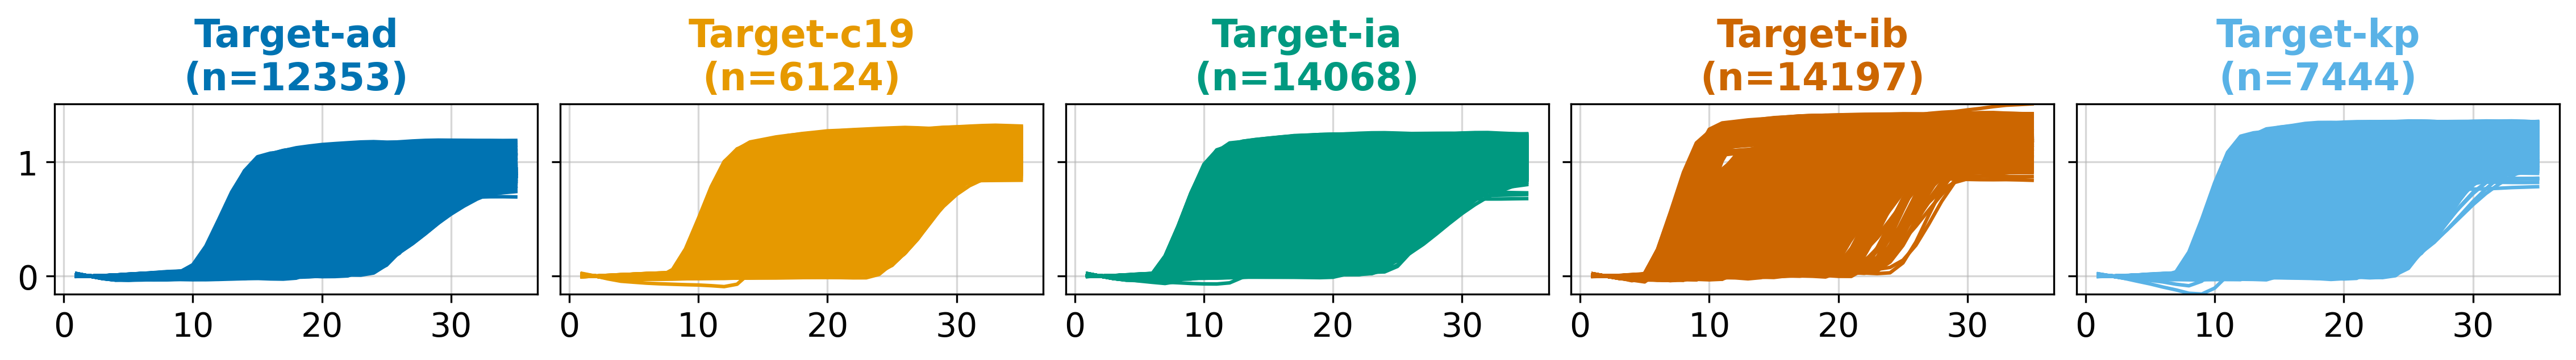

In [32]:
%autoreload
import utilities as utils
NMETA = 7

y_lim_min, y_lim_max = df_dlamp_ampl.iloc[:, NMETA:].values.min(), df_dlamp_ampl.iloc[:, NMETA:].values.max()

filename = 'Images/dLAMP_amplification_curves.png'
utils.plot_amplification_curves(df_dlamp_ampl, NMETA=NMETA, ylim=(y_lim_min, y_lim_max), filename=filename, target_column="Target")

/Users/kautsarg/Library/CloudStorage/OneDrive-ImperialCollegeLondon/Final Project/3. Initial code/titan-signal-processing-main/gk_code/0_6_AMCA Code on dLAMP/pyAMCA/utilities.py:12: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  
/Users/kautsarg/Library/CloudStorage/OneDrive-ImperialCollegeLondon/Final Project/3. Initial code/titan-signal-processing-main/gk_code/0_6_AMCA Code on dLAMP/pyAMCA/utilities.py:12: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For 

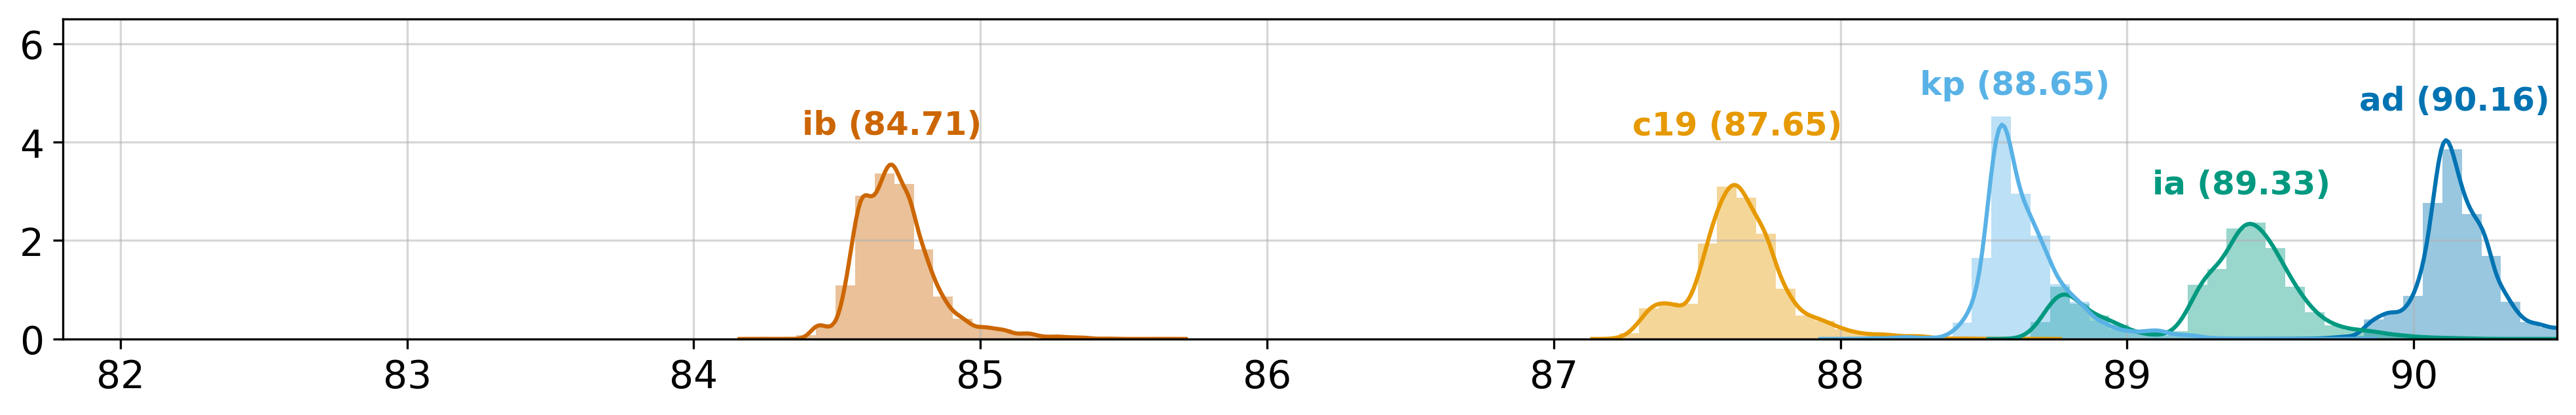

,ad,c19,ia,ib,kp
Mean,90.161947,87.648513,89.325503,84.708234,88.645822
Median,90.142406,87.640796,89.399108,84.692233,88.608425
MaxLikelihood,90.112367,87.626767,89.427924,84.691783,88.563511
Std,0.152999,0.166865,0.291970,0.137265,0.149644
IQR,0.148965,0.174453,0.258331,0.157341,0.155784


In [41]:
%autoreload
import utilities as utils

filename = 'Images/dLAMP_melting_peaks.png'
utils.plot_melt_peak_distributions(df_dlamp_ampl, filename=filename)

In [23]:
# df_dlamp_melpt = pd.read_csv('Data/dLAMP_Melting_Curves.csv', 
#                            index_col=0)

# df_dlamp_melpt.head()

In [ ]:
# df_dpcr_melt.shape

(58664, 70)

In [24]:
# filename = 'Images/dPCR_melting_curves.png'
# utils.plot_melt_curves(df_dpcr_melt, NMETA=7, ylim=(0, 0.12), filename=filename)

# Data Analysis
## Organise Data

In [33]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegressionCV

X_AC = df_dlamp_ampl.iloc[:, NMETA:].values
X_MC = df_dlamp_ampl.loc[:, ['MeltPeaks']].values
X_FFI = X_AC[:,[-1]]

encoder = LabelEncoder()
encoder.fit(df_dlamp_ampl['Target'])
ytrue = encoder.transform(df_dlamp_ampl['Target'])

X_MC.shape, X_AC.shape, X_FFI.shape, ytrue.shape

((54186, 1), (54186, 35), (54186, 1), (54186,))

0 12353
12353 6124
18477 14068
32545 14197
46742 7444


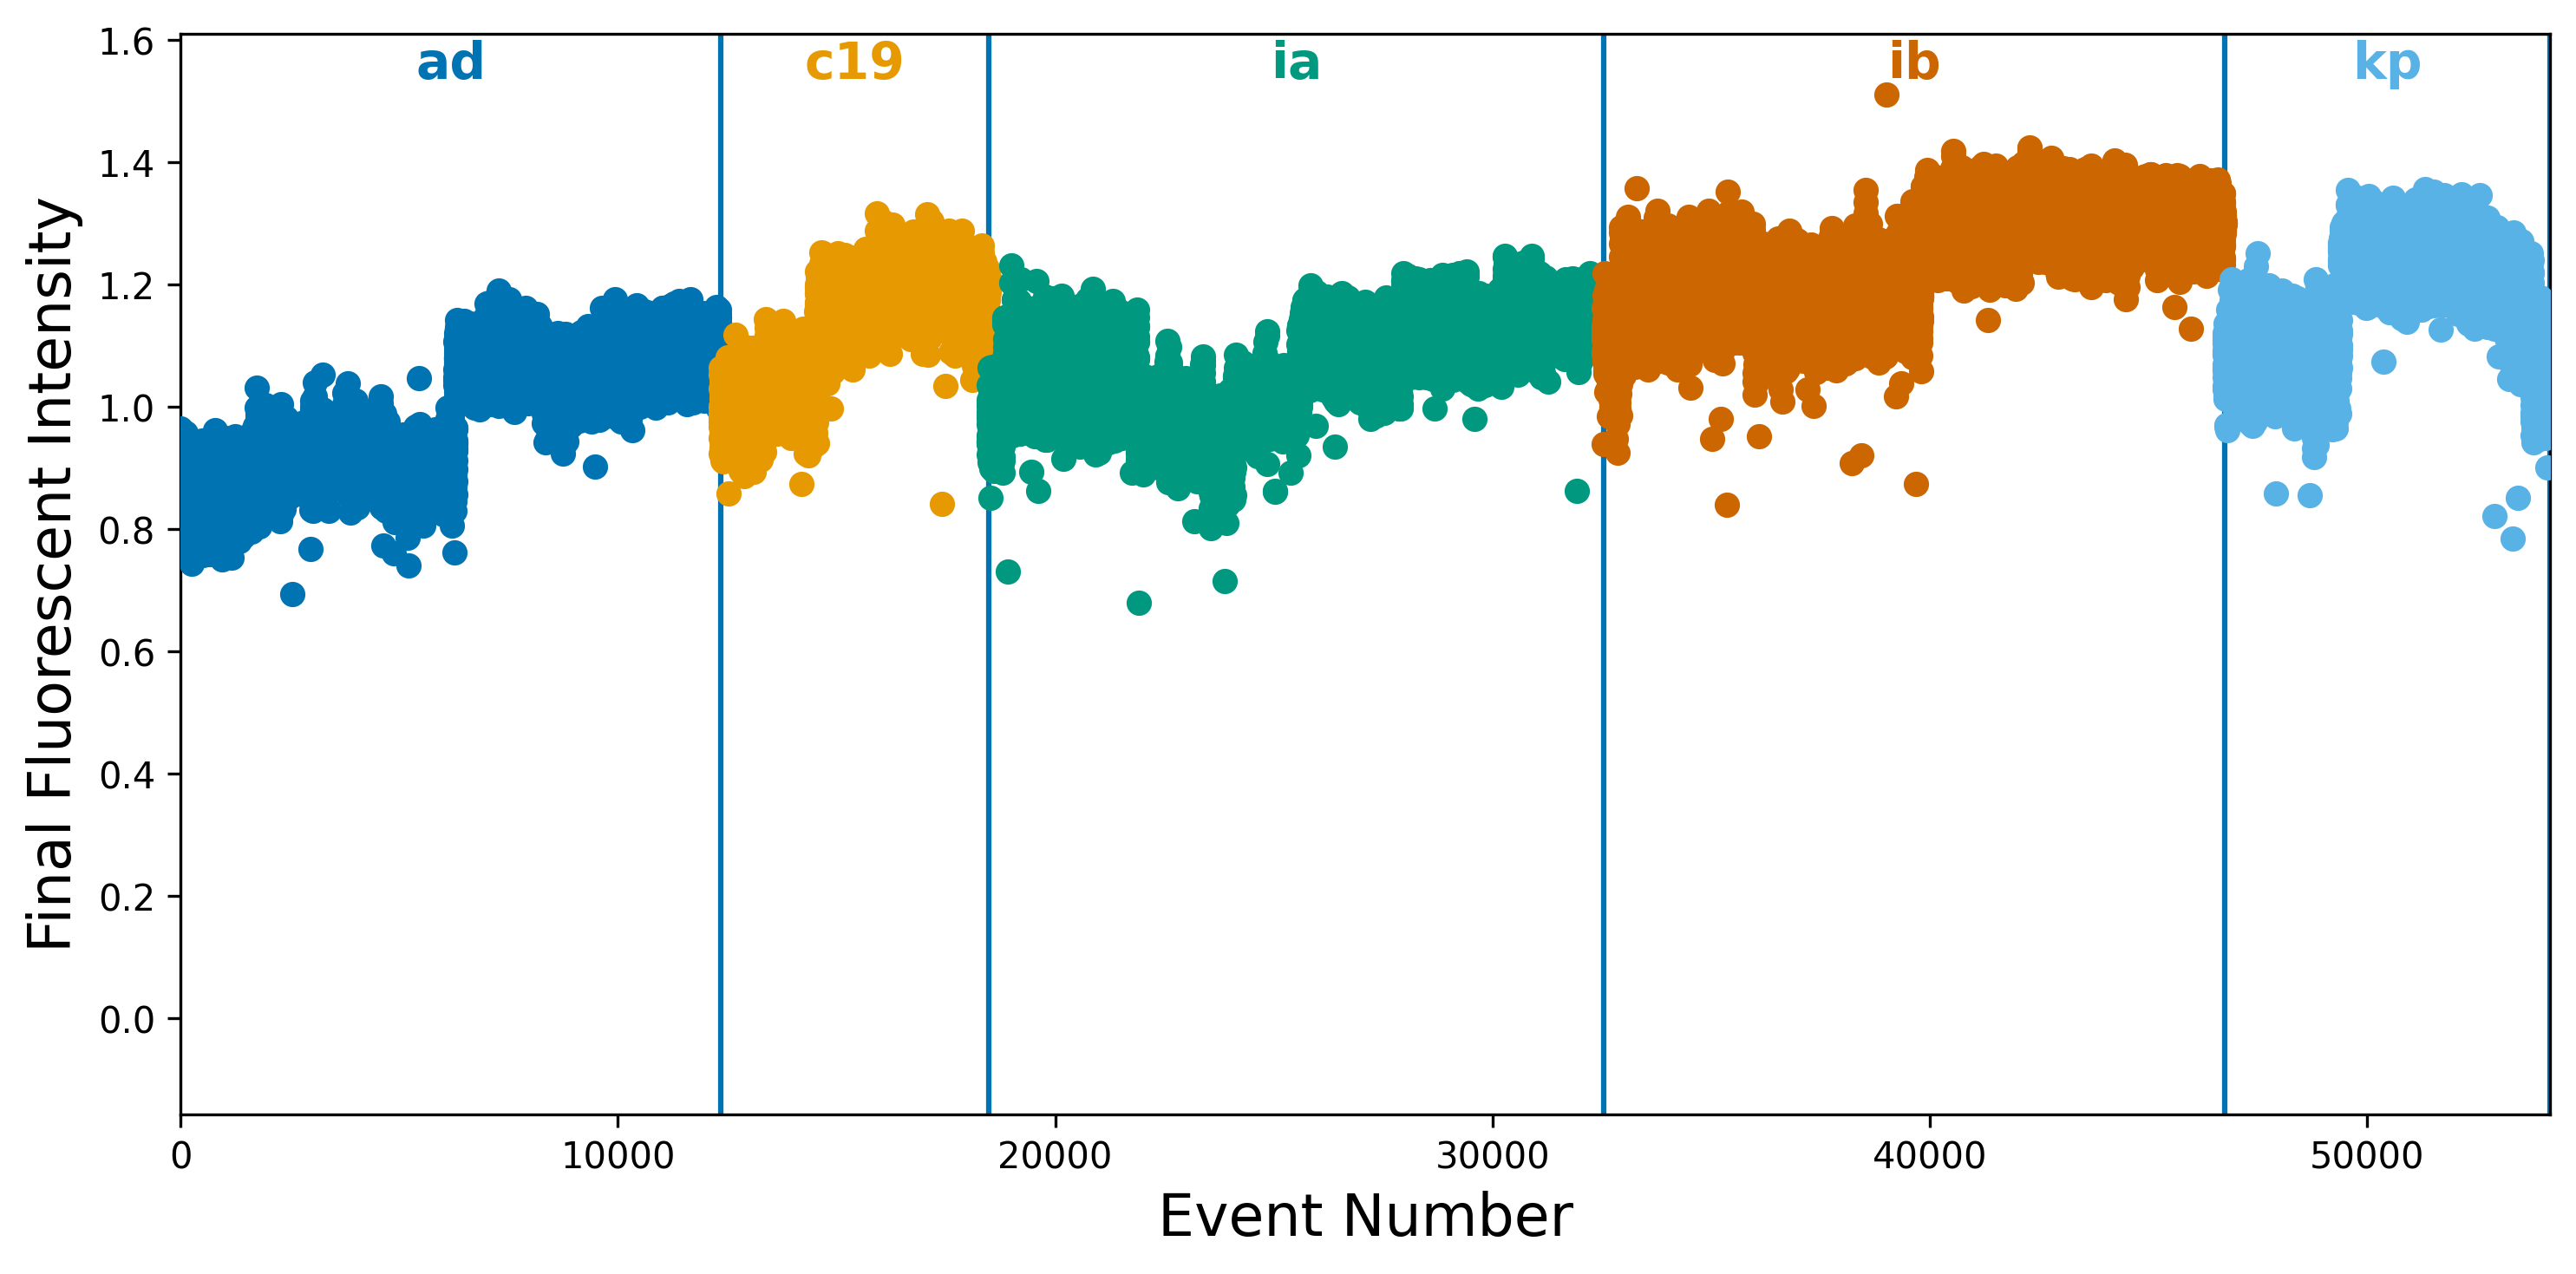

In [40]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5), dpi=300)

cnt = 0
for i in np.unique(ytrue):
    idx = ytrue==i
    print(cnt, np.sum(idx))
    ax.scatter(np.arange(np.sum(idx)) + cnt, X_FFI[idx], color=f'C{i}', zorder=100)
    
    ax.text(cnt + np.sum(idx)/2, y_lim_max+0.05, encoder.classes_[i], color=f'C{i}', fontsize=14, weight='bold',
            horizontalalignment='center', verticalalignment='center')
    
    cnt += np.sum(idx)
    
    ax.vlines(cnt, y_lim_min, y_lim_max+0.1)
    
    
ax.set_xlim((0, len(X_FFI)))
ax.set_ylim((y_lim_min, y_lim_max+0.1))

ax.set_ylabel('Final Fluorescent Intensity', fontsize=16)
ax.set_xlabel('Event Number', fontsize=16)

# ax.grid(True)

plt.tight_layout()
plt.savefig('Images/dPCR_FFI_Dist.png')
plt.show()

## Define ACA Model (Neural Network)

In [47]:
import tensorflow as tf
from scikeras.wrappers import KerasClassifier

class myWrapper(KerasClassifier):
    # def predict(self, X):
    #     return self.model.predict(X).argmax(axis=1)
    
    # def predict_proba(self, X):
    #     return self.model.predict(X)
    pass

display(f'TF VERSION: {tf.__version__}')

def create_model(): # 70% WE USED FOR THE FIRST TIME TNSOR BOARD
    # TIMESTEPS, CHANNELS
    inputs = tf.keras.layers.Input(shape=(X_AC.shape[1], 1))
    x = tf.keras.layers.Conv1D(16, 5, activation='relu')(inputs)
    x = tf.keras.layers.Conv1D(8, 3, activation='relu')(x)
    x = tf.keras.layers.Flatten()(x)
    x = tf.keras.layers.Dense(len(np.unique(ytrue)), activation='softmax')(x)
    model = tf.keras.models.Model(inputs=inputs, outputs=x)
    model.compile(optimizer='adam', 
                  loss='sparse_categorical_crossentropy', 
                  metrics=['accuracy'])
    return model

tf_net = create_model()
tf_net.summary()

'TF VERSION: 2.21.0'

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 35, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_10 (Conv1D)              │ (None, 31, 16)         │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_11 (Conv1D)              │ (None, 29, 8)          │           392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 232)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │         1,165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,653 (6.46 KB)

 Trainable params: 1,653 (6.46 KB)

 Non-trainable params: 0 (0.00 B)

## Train and Compute Performance (10-Fold Cross Val)

In [49]:
from sklearn.neighbors import KNeighborsClassifier

N_SPLITS = 10

kfolds = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=0)
splits = kfolds.split(X_AC, ytrue)

y_trues_ = []

y_preds_AC_ = []
y_preds_AC_KNN_ = []

y_preds_MC_ = []

y_preds_FFI_ = []

y_preds_AMCA_ = []
y_preds_AMCA_kNN_ = []

for i, (train_index, test_index) in enumerate(tqdm(splits, total=N_SPLITS)):

    X_MC_train, X_MC_test = X_MC[train_index], X_MC[test_index]
    X_AC_train, X_AC_test = X_AC[train_index], X_AC[test_index]
    X_FFI_train, X_FFI_test = X_FFI[train_index], X_FFI[test_index]
    
    y_train, y_test = ytrue[train_index], ytrue[test_index]
    y_trues_.append(y_test)

    ########## create/train model for AC ##########
    clf_AC = myWrapper(build_fn=create_model, 
                            epochs=1000, 
                            batch_size=512, 
                            shuffle=True,
                            verbose=False)
    clf_AC.fit(X_AC_train, y_train)
    clf_AC_proba = clf_AC.predict_proba(X_AC_train)
    y_preds_AC_.append( clf_AC.predict(X_AC_test) )
    
    ########## create/train model for AC with KNN##########
    clf_AC_kNN = KNeighborsClassifier(n_neighbors=10)
    clf_AC_kNN.fit(X_AC_train, y_train)
    clf_AC_kNN_proba = clf_AC_kNN.predict_proba(X_AC_train)
    y_preds_AC_KNN_.append(clf_AC_kNN.predict(X_AC_test))

    ########## create/train model for MC ##########    
    clf_MC = LogisticRegression(max_iter=1000)
    clf_MC.fit(X_MC_train, y_train)
    clf_MC_proba = clf_MC.predict_proba(X_MC_train)
    y_preds_MC_.append(clf_MC.predict(X_MC_test))

    ########## create/train model for FFI ##########
    clf_FFI = LogisticRegression(max_iter=1000)
    clf_FFI.fit(X_FFI_train, y_train)
    y_preds_FFI_.append(clf_FFI.predict(X_FFI_test))

    ########## create/train model for AMCA ##########
    X_AMCA_train = np.concatenate((clf_MC_proba, clf_AC_proba), axis=1)
    X_AMCA_test = np.concatenate((clf_MC.predict_proba(X_MC_test), 
                                   clf_AC.predict_proba(X_AC_test)), axis=1)
    
    clf_AMCA = LogisticRegression(max_iter=1000, fit_intercept=False)
    clf_AMCA.fit(X_AMCA_train, y_train)
    y_preds_AMCA_.append(clf_AMCA.predict(X_AMCA_test))

    ########## create/train model for AMCA kNN ##########
    X_AMCA_kNN_train = np.concatenate((clf_MC_proba, clf_AC_kNN_proba), axis=1)
    X_AMCA_kNN_test = np.concatenate((clf_MC.predict_proba(X_MC_test), 
                                   clf_AC_kNN.predict_proba(X_AC_test)), axis=1)
    
    clf_AMCA_kNN = LogisticRegression(max_iter=1000, fit_intercept=False)
    clf_AMCA_kNN.fit(X_AMCA_kNN_train, y_train)
    y_preds_AMCA_kNN_.append(clf_AMCA_kNN.predict(X_AMCA_kNN_test))

    
y_trues = np.concatenate(y_trues_)

y_preds_AC = np.concatenate(y_preds_AC_)
y_preds_AC_kNN = np.concatenate(y_preds_AC_KNN_)
y_preds_MC = np.concatenate(y_preds_MC_)
y_preds_FFI = np.concatenate(y_preds_FFI_)
y_preds_AMCA = np.concatenate(y_preds_AMCA_)
y_preds_AMCA_kNN = np.concatenate(y_preds_AMCA_kNN_)

  0%|          | 0/10 [00:00<?, ?it/s]/Users/kautsarg/Library/CloudStorage/OneDrive-ImperialCollegeLondon/Final Project/3. Initial code/titan-signal-processing-main/venv_titan/lib/python3.12/site-packages/scikeras/wrappers.py:925: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)
 10%|█         | 1/10 [02:37<23:34, 157.14s/it]/Users/kautsarg/Library/CloudStorage/OneDrive-ImperialCollegeLondon/Final Project/3. Initial code/titan-signal-processing-main/venv_titan/lib/python3.12/site-packages/scikeras/wrappers.py:925: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)
 20%|██        | 2/10 [05:00<19:53, 149.13s/it]/Users/kautsarg/Library/CloudStorage/OneDrive-ImperialCollegeLondon/Final Project/3. Initial code/titan-signal-processing-main/venv_titan/

In [51]:
from sklearn.metrics import accuracy_score
import statsmodels.api as sm
from scipy.stats import bartlett, ttest_ind

acc_for_each_fold = lambda x: [accuracy_score(i, j) for i, j in zip(x, y_trues_)]

acc_dict = {'FFI': acc_for_each_fold(y_preds_FFI_),
            'ACA': acc_for_each_fold(y_preds_AC_),
            'ACA_kNN': acc_for_each_fold(y_preds_AC_KNN_),
            'MCA': acc_for_each_fold(y_preds_MC_),
            'AMCA': acc_for_each_fold(y_preds_AMCA_),
            'AMCA_kNN': acc_for_each_fold(y_preds_AMCA_kNN_),}
acc = pd.DataFrame(acc_dict)

normality_test = lambda x: sm.stats.lilliefors(x)[1]

variance_test = lambda x: bartlett(x, acc['AMCA'])[1]

ttest = lambda x: ttest_ind(x, acc['AMCA'], equal_var=False)[1]

statistics = lambda x: [np.mean(x), np.std(x), normality_test(x), variance_test(x), ttest(x)]

stats = pd.DataFrame({k: statistics(acc[k]) for k in acc.columns})

stats.index = ['Mean Acc.', 'Std Acc.', 'Normality p-val.', 'Equal Var. p-val', 'Ttest p-val']

pd.set_option('display.float_format', lambda x: f'{x:.4f}')

stats

,FFI,ACA,ACA_kNN,MCA,AMCA,AMCA_kNN
Mean Acc.,0.4832,0.9423,0.9227,0.9456,0.9904,0.9889
Std Acc.,0.0057,0.0043,0.0024,0.0025,0.0013,0.0012
Normality p-val.,0.9099,0.1980,0.2521,0.7730,0.3570,0.3079
Equal Var. p-val,0.0002,0.0017,0.0819,0.0800,1.0000,0.7384
Ttest p-val,0.0000,0.0000,0.0000,0.0000,1.0000,0.0173


In [52]:
np.save('Data/my_coeff', clf.coef_)

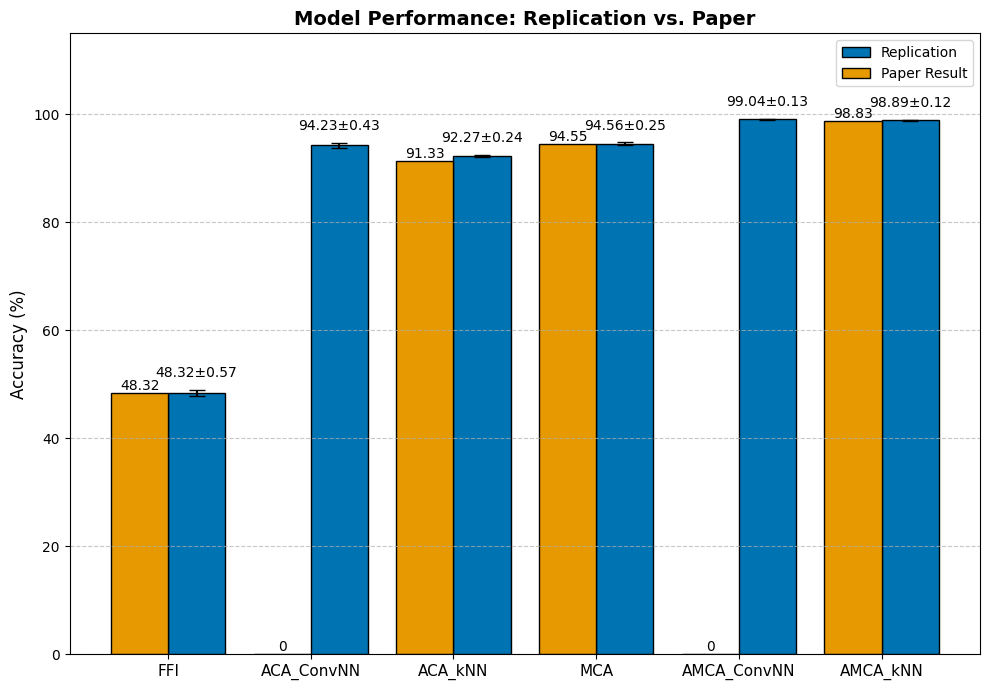

In [74]:
classes = encoder.classes_

ypreds_methods = [y_preds_FFI_, y_preds_AC_, y_preds_AC_KNN_, y_preds_MC_, y_preds_AMCA_, y_preds_AMCA_kNN_]
titles = ['Final Fluorescence Intensity',
          'Amplification Curve Analysis',
          'Amplification Curve Analysis (kNN)',
          'Melting Curve Analysis',
          'Amplification and Melting Curve Analysis',
          'Amplification and Melting Curve Analysis (kNN)']
short_names = ['FFI', 'ACA_ConvNN', 'ACA_kNN', 'MCA', 'AMCA_ConvNN', 'AMCA_kNN']

paper_result = [48.32, 0, 91.33, 94.55, 0, 98.83]

accs_mean = []
accs_std = []
for yps in ypreds_methods:
    acc_temp = []
    for yp, y_tr in zip(yps, y_trues_):
        acc_temp.append(accuracy_score(y_tr, yp)*100)
    accs_mean.append(np.mean(acc_temp))
    accs_std.append(np.std(acc_temp))

# Labels for the replication bars
custom_labels = [f'{a:.2f}±{s:.2f}' for a, s in zip(accs_mean, accs_std)]

# Plotting setup
x = np.arange(len(short_names))
width = 0.4  # Width of each bar

fig, ax = plt.subplots(figsize=(10, 7))

# Plot Replication bars (with error bars)
bars_rep = ax.bar(x + width/2, accs_mean, width, yerr=accs_std, capsize=6, 
                  edgecolor='black', label='Replication')

# Plot Paper bars
bars_paper = ax.bar(x - width/2, paper_result, width, 
                    edgecolor='black', label='Paper Result')

# Add labels on top of bars
ax.bar_label(bars_paper, padding=0, fontsize=10)
ax.bar_label(bars_rep, labels=custom_labels, padding=7, fontsize=10)


# Formatting
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Model Performance: Replication vs. Paper', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(short_names, fontsize=11)
ax.set_ylim(0, 115) 
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [78]:
print(short_names)
print(paper_result)
print(accs_mean)
print(accs_std)

['FFI', 'ACA_ConvNN', 'ACA_kNN', 'MCA', 'AMCA_ConvNN', 'AMCA_kNN']
[48.32, 0, 91.33, 94.55, 0, 98.83]
[np.float64(48.31873531129379), np.float64(94.23282625812914), np.float64(92.27106905681859), np.float64(94.56132330695131), np.float64(99.04218515019443), np.float64(98.88716648577517)]
[np.float64(0.5737939391771157), np.float64(0.4288367272569513), np.float64(0.24416062940002045), np.float64(0.24515769917573677), np.float64(0.13220004556689868), np.float64(0.11790024931772496)]


In [58]:
y_trues

array([0, 0, 0, ..., 4, 4, 4], shape=(54186,))

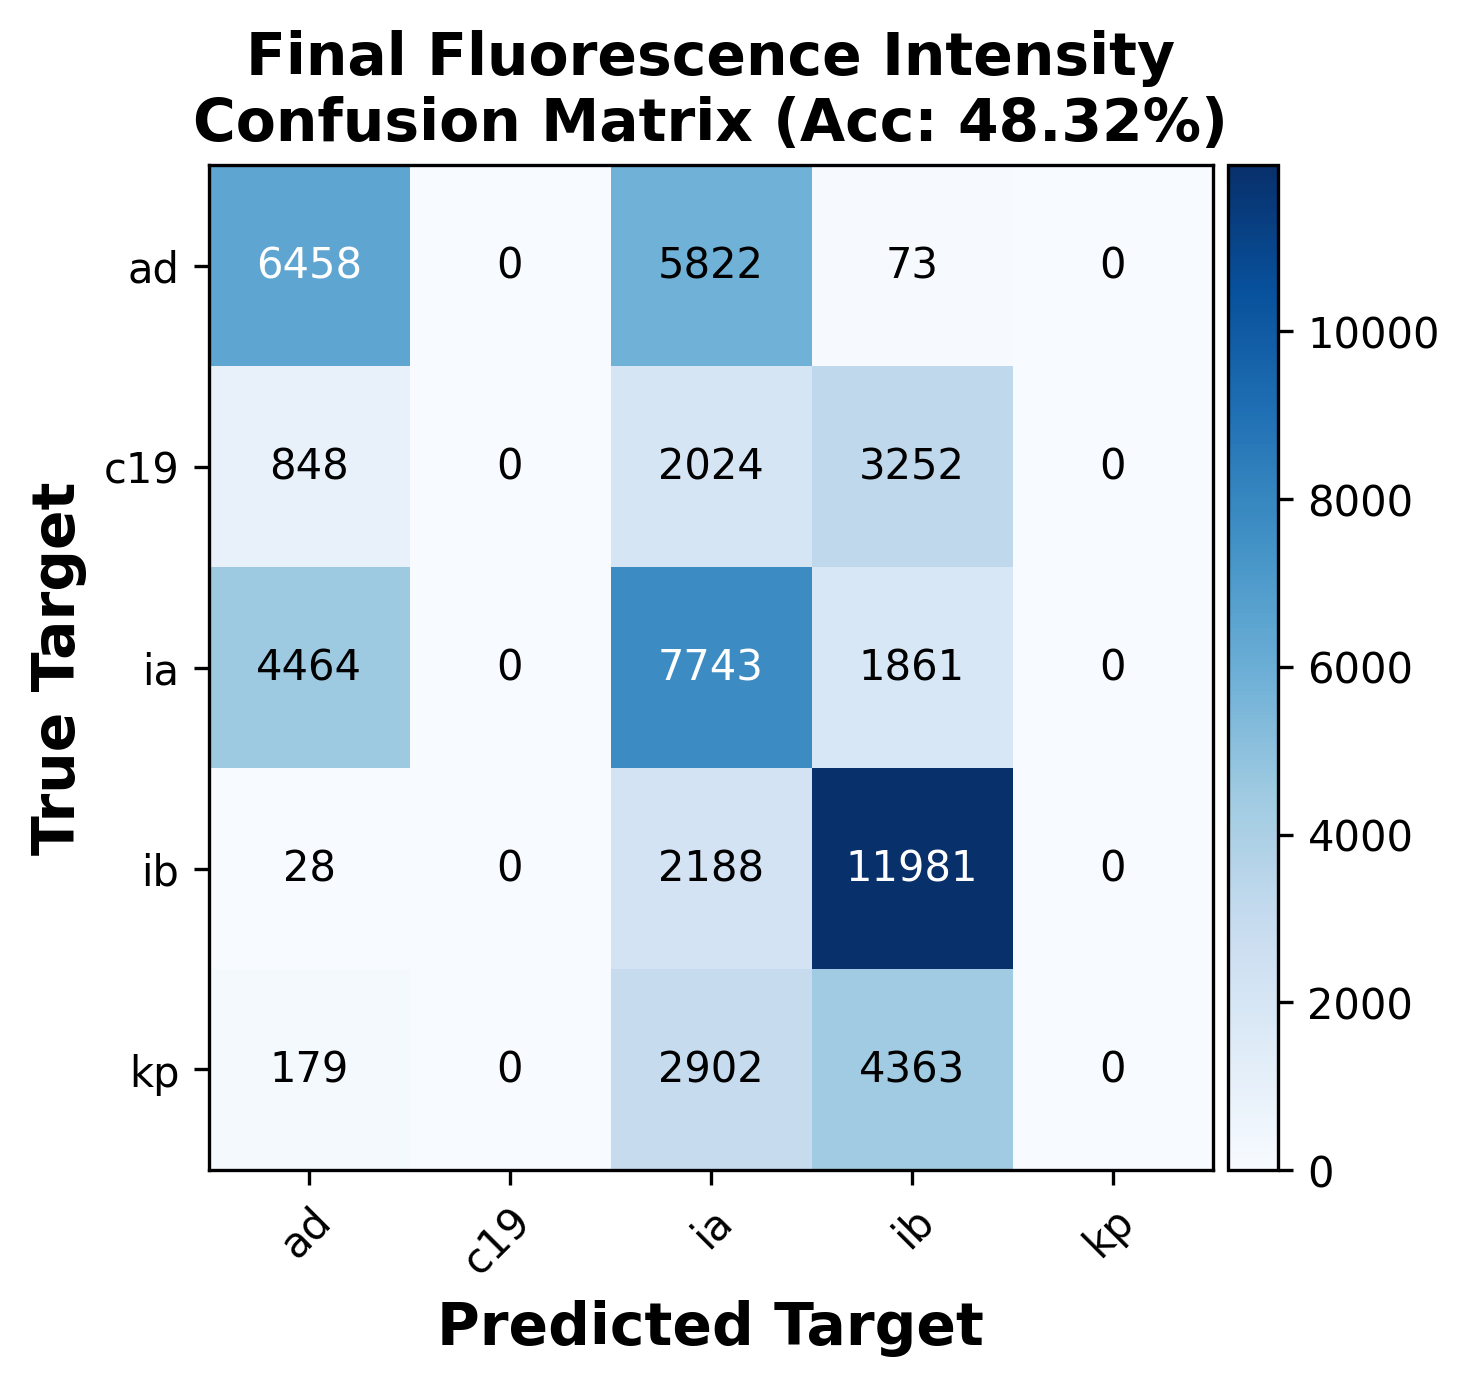

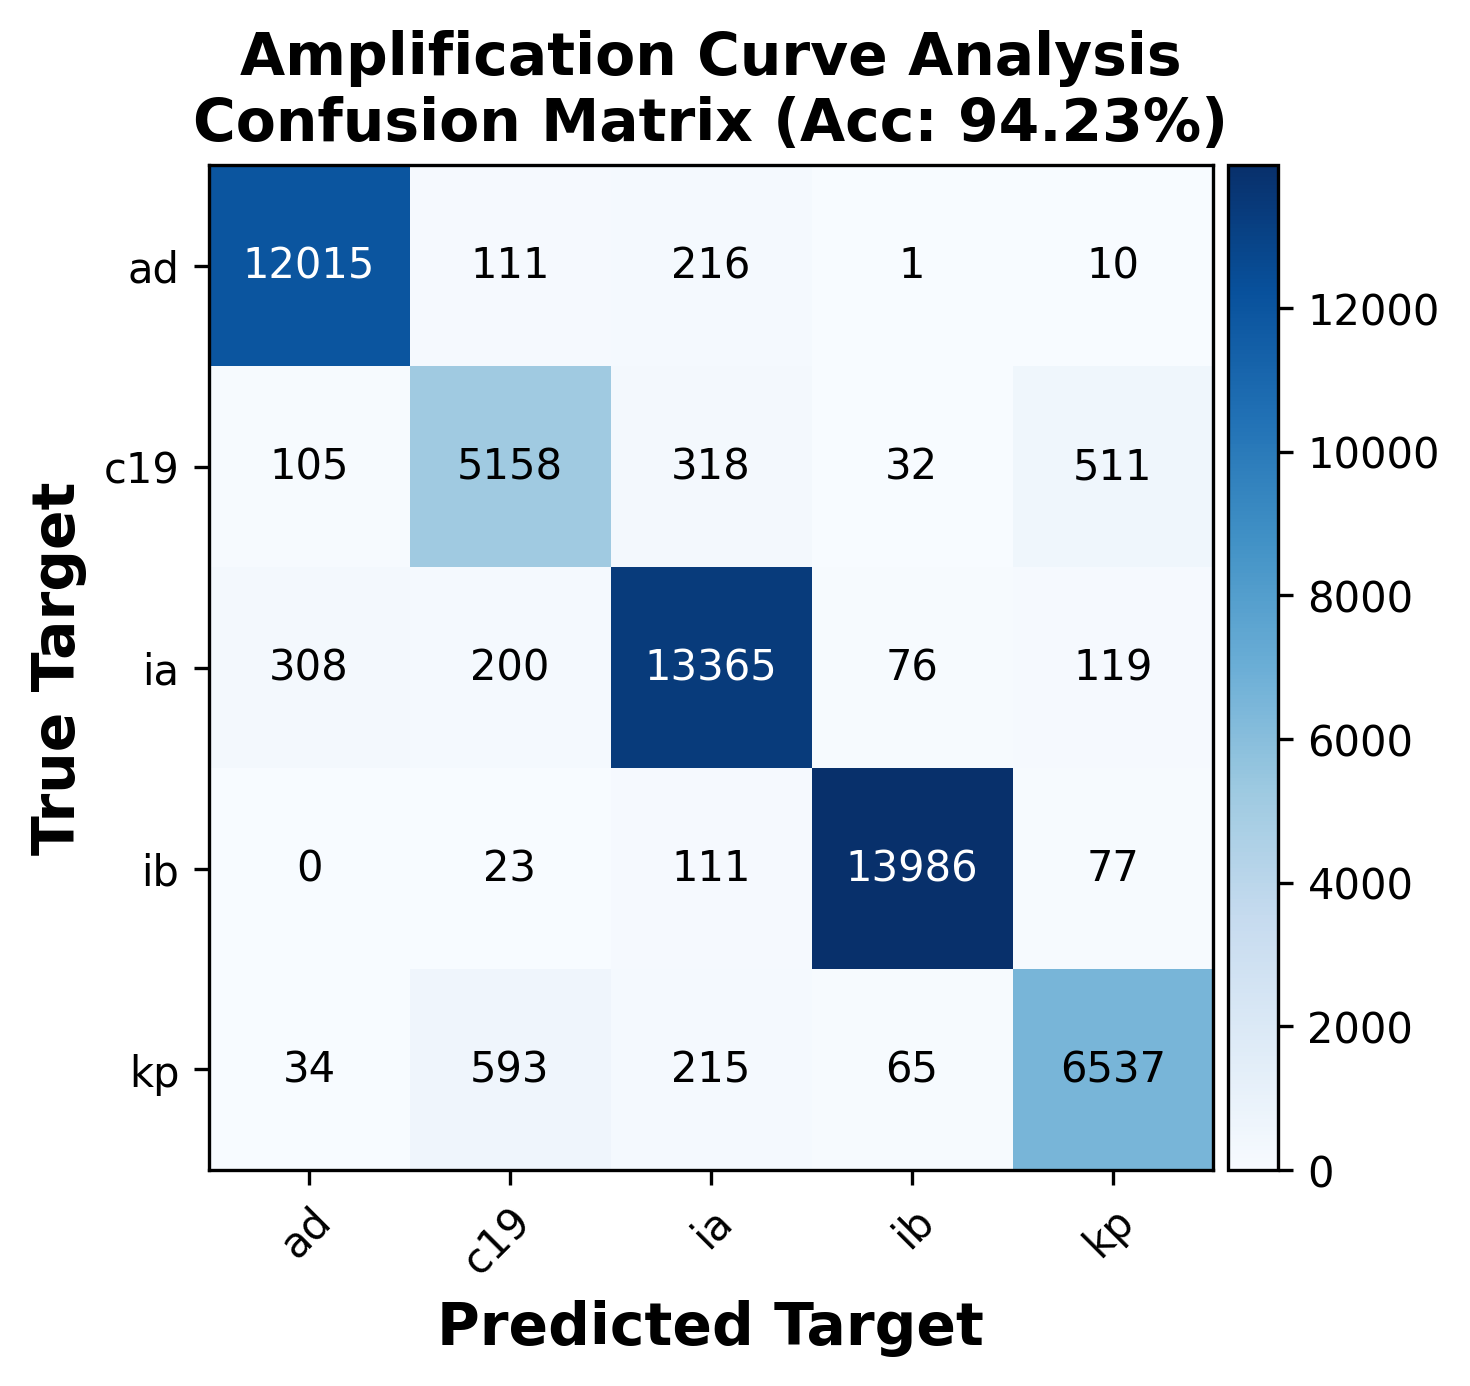

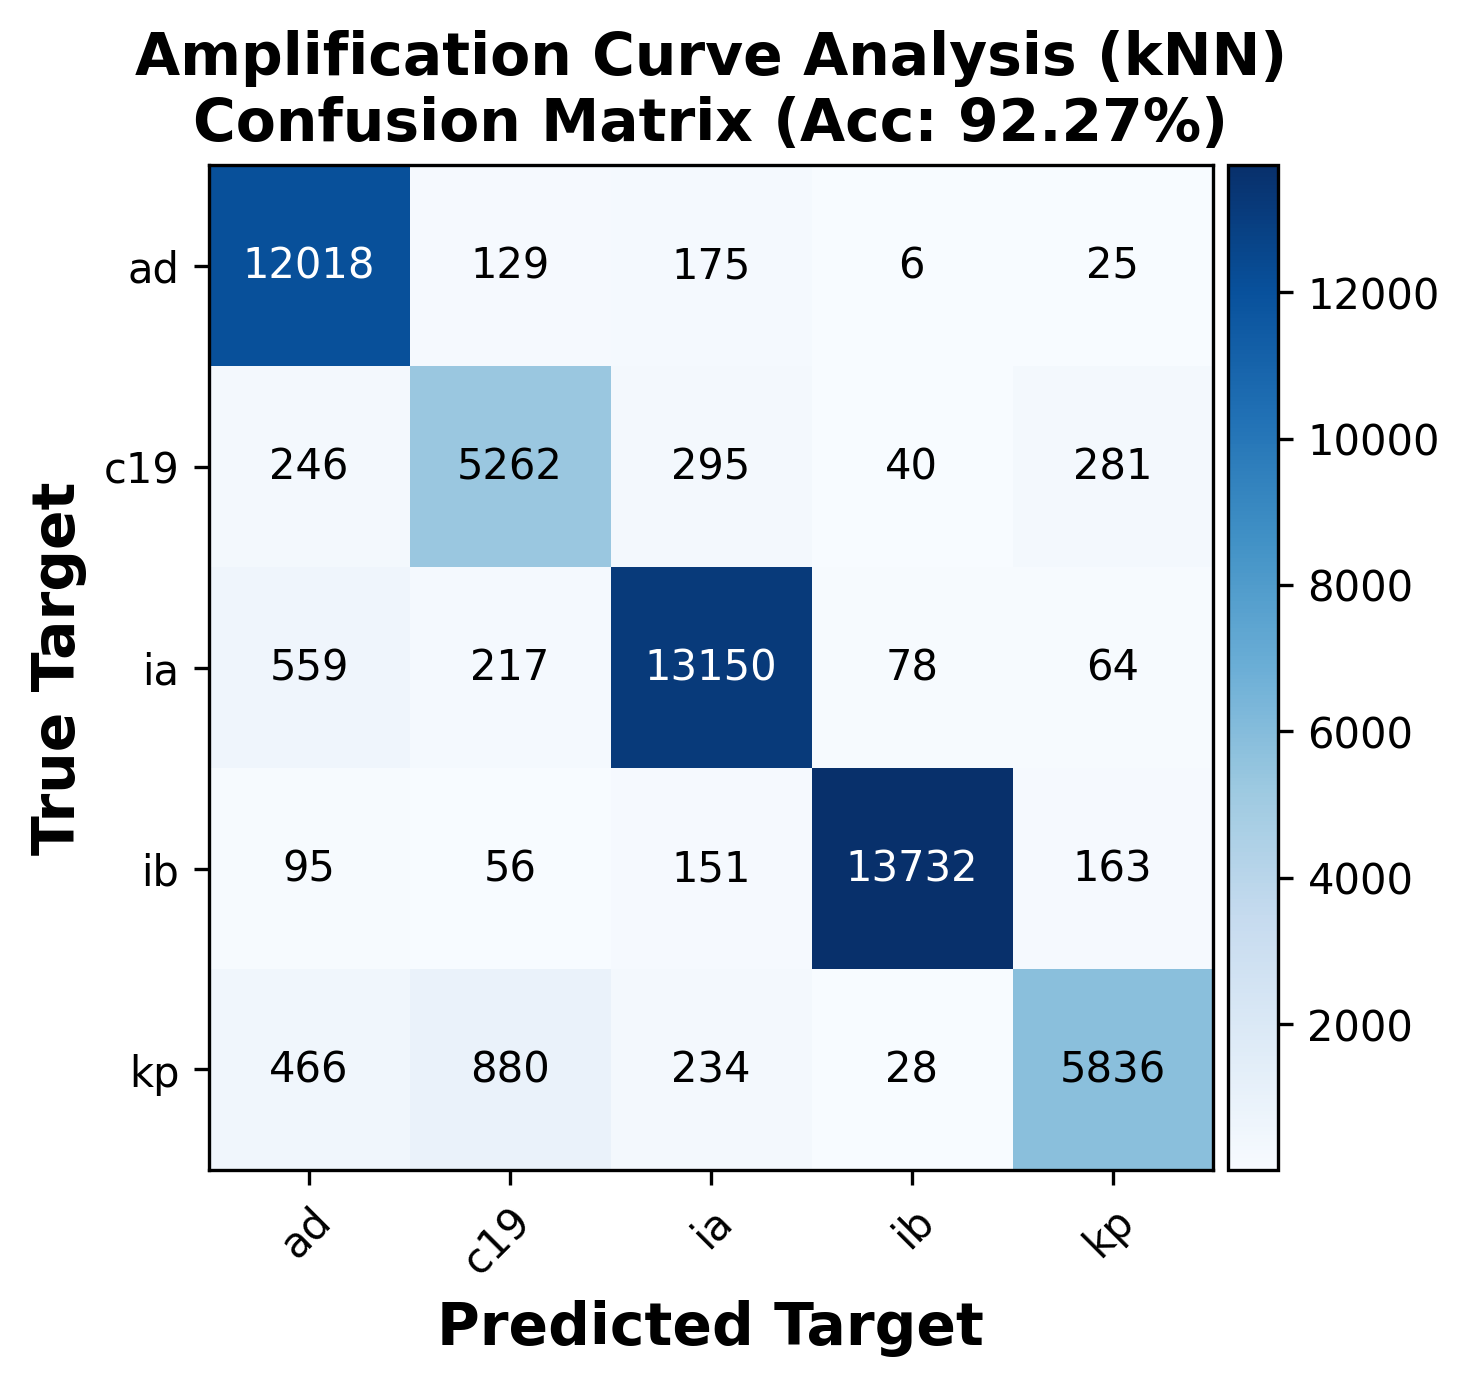

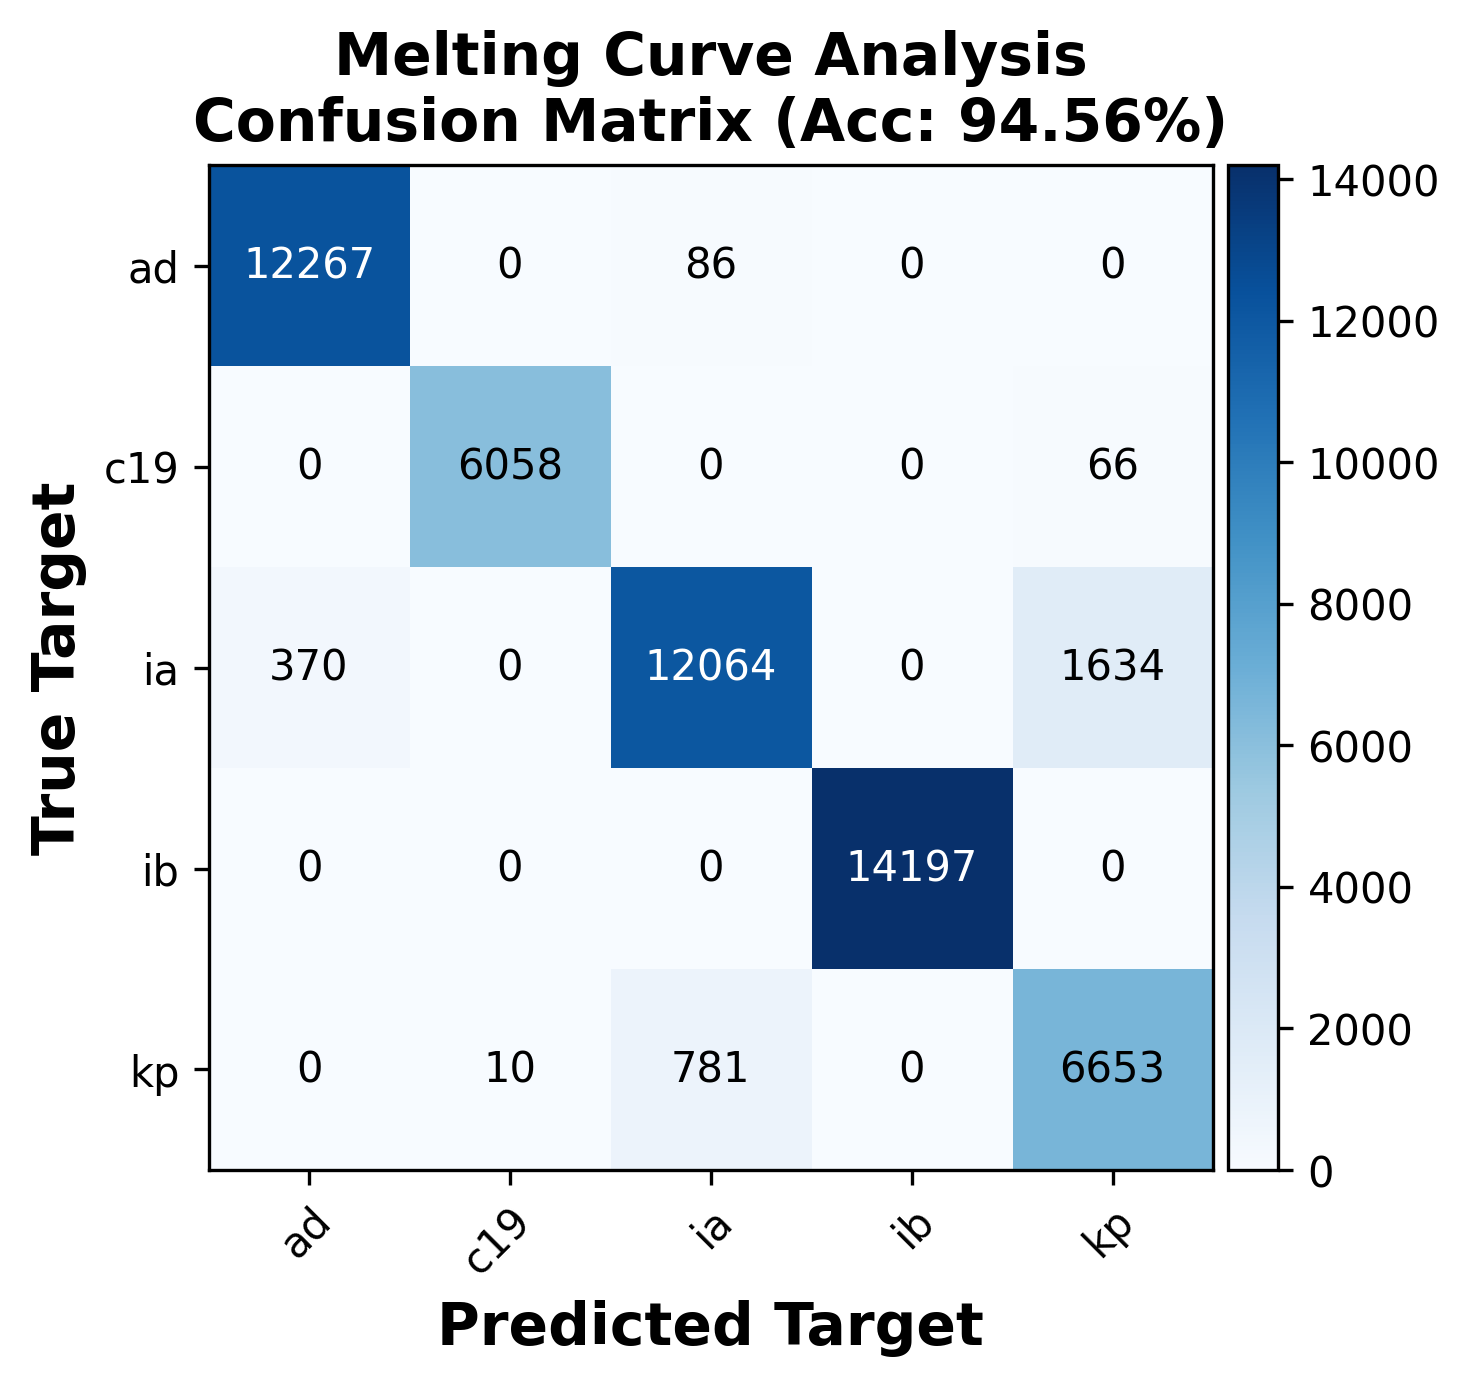

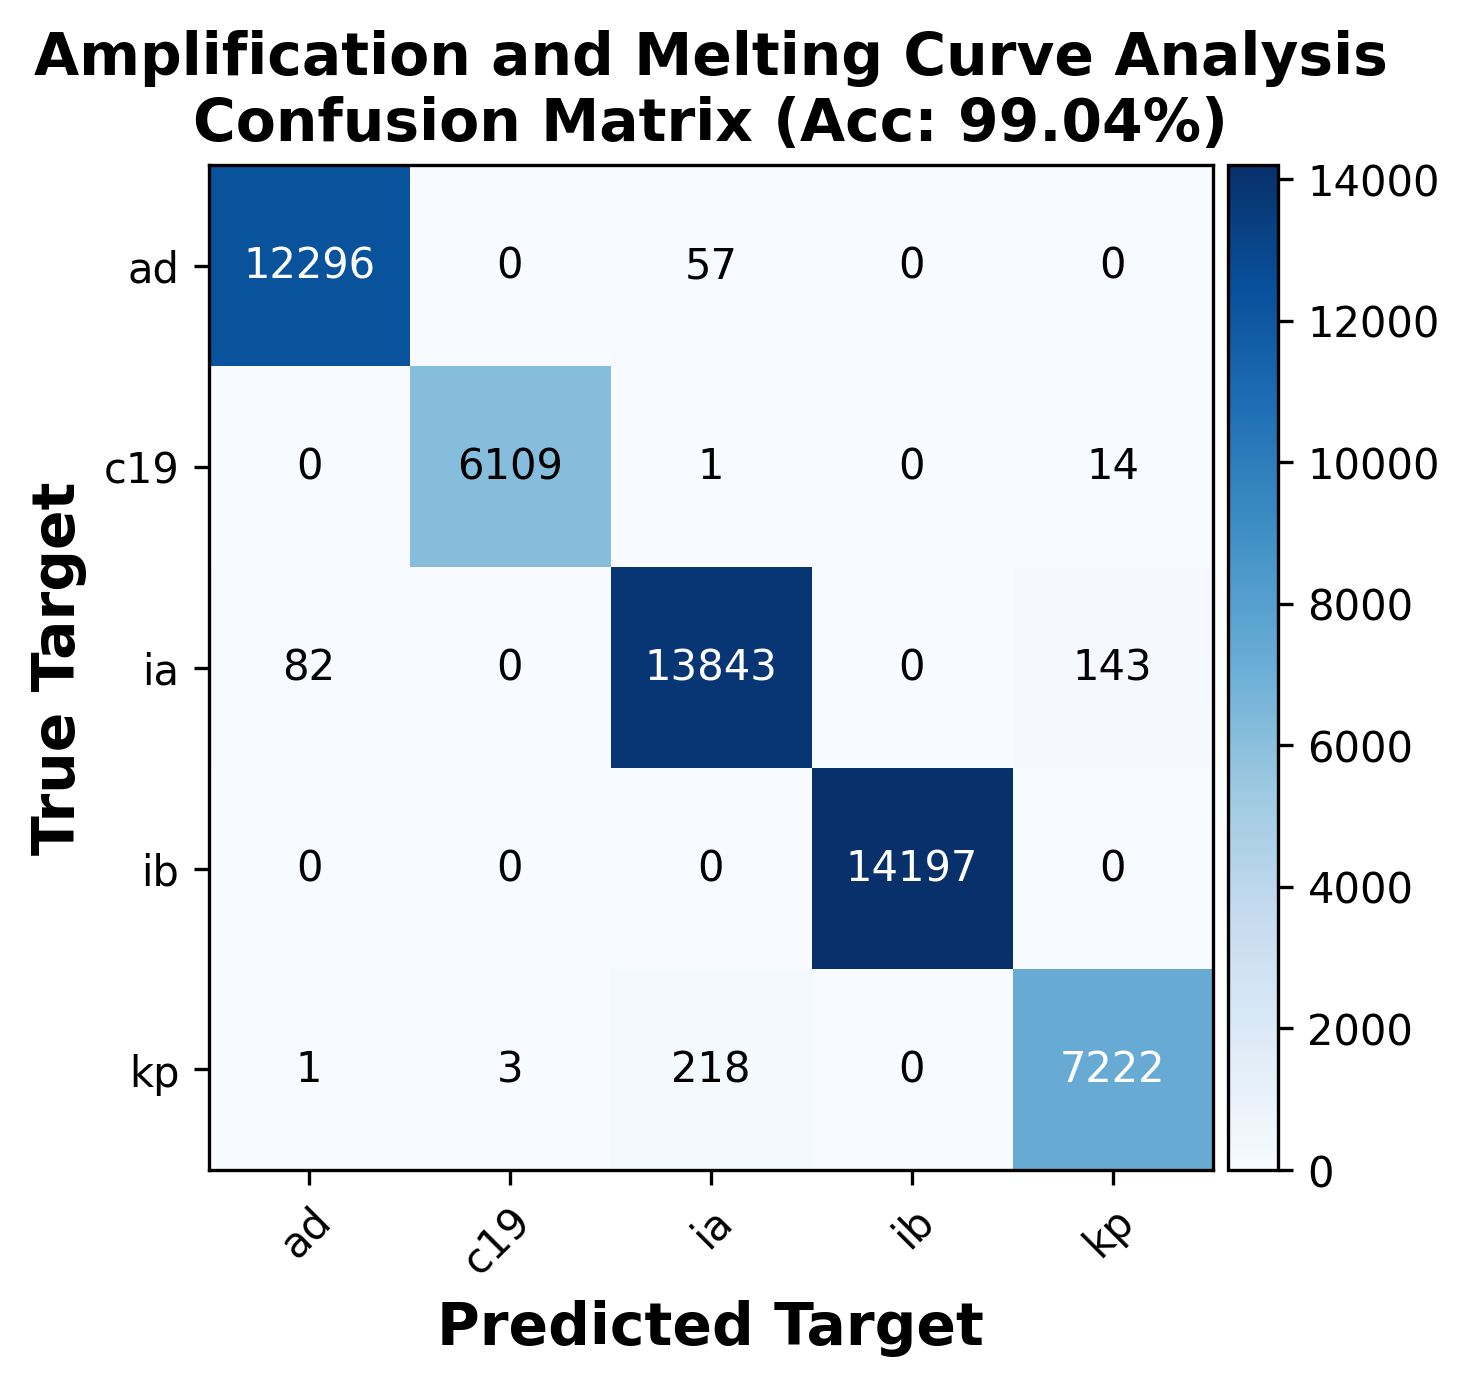

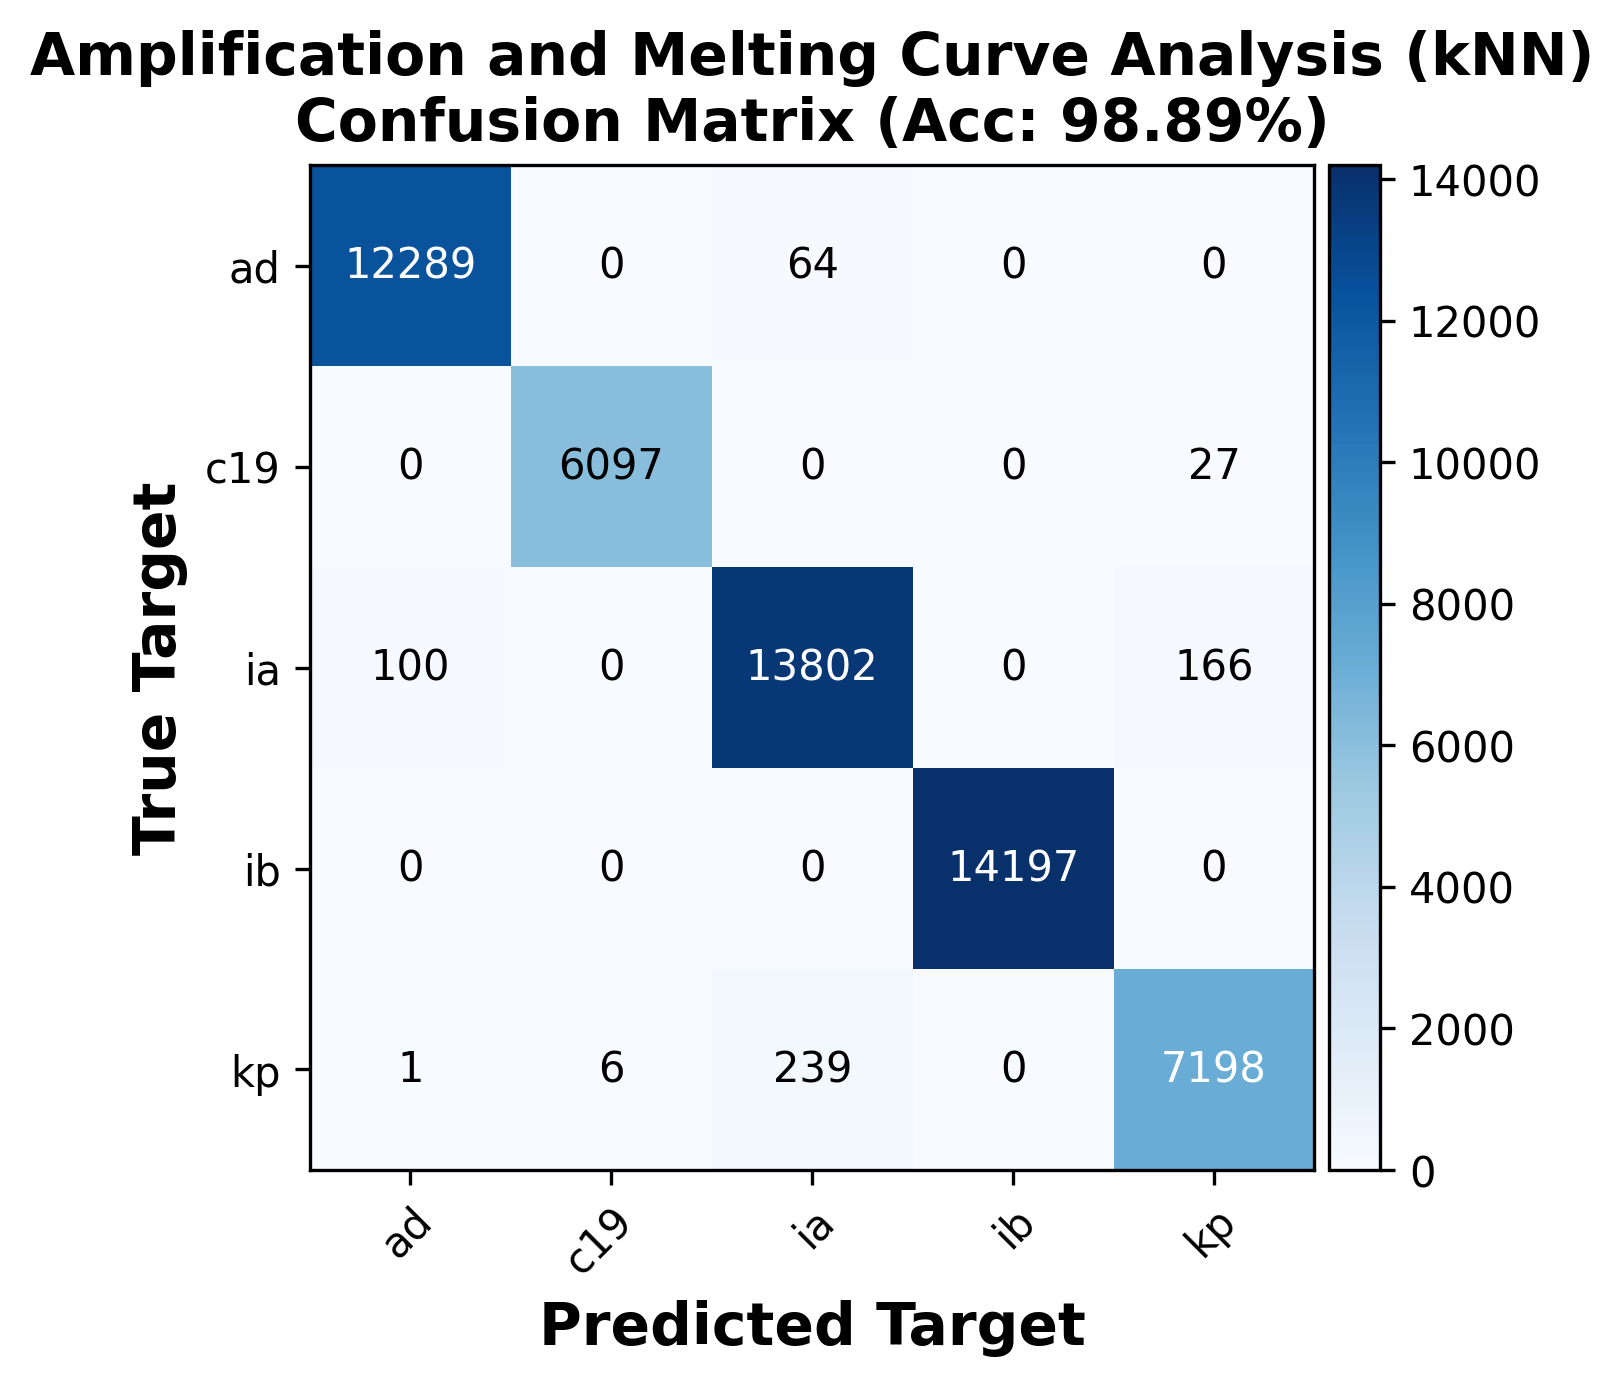

In [61]:
classes = encoder.classes_

ypreds_methods = [y_preds_FFI, y_preds_AC, y_preds_AC_kNN, y_preds_MC, y_preds_AMCA, y_preds_AMCA_kNN]
titles = ['Final Fluorescence Intensity',
          'Amplification Curve Analysis',
          'Amplification Curve Analysis (kNN)',
          'Melting Curve Analysis',
          'Amplification and Melting Curve Analysis',
          'Amplification and Melting Curve Analysis (kNN)']
short_names = ['FFI', 'ACA', 'ACA_kNN', 'MCA', 'AMCA', 'AMCA_kNN']

for yp, title, short_name in zip(ypreds_methods, titles, short_names):

    fig, ax = plt.subplots(1, 1, figsize=(5, 5), dpi=300)

    utils.plot_confusion_matrix(y_trues, yp, classes, ax, normalize=False)
    ax.set_title(f'{title}\n'+ax.get_title(), fontsize=14, weight='bold')
    ax.set_ylabel('True Target', fontsize=14, weight='bold')
    ax.set_xlabel('Predicted Target', fontsize=14, weight='bold')

    plt.tight_layout()
    plt.savefig(f'Images/dPCR_{short_name}.pdf')
    plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix

np.set_printoptions(precision=3, suppress=True)

a = 100*confusion_matrix(y_trues, y_preds, normalize='true')

a.sum(axis=1) - np.diagonal(a)

array([0.798, 0.305, 0.341, 0.153, 0.965, 1.691, 0.321, 0.784, 0.273])

## Visualise AMCA Coefficients

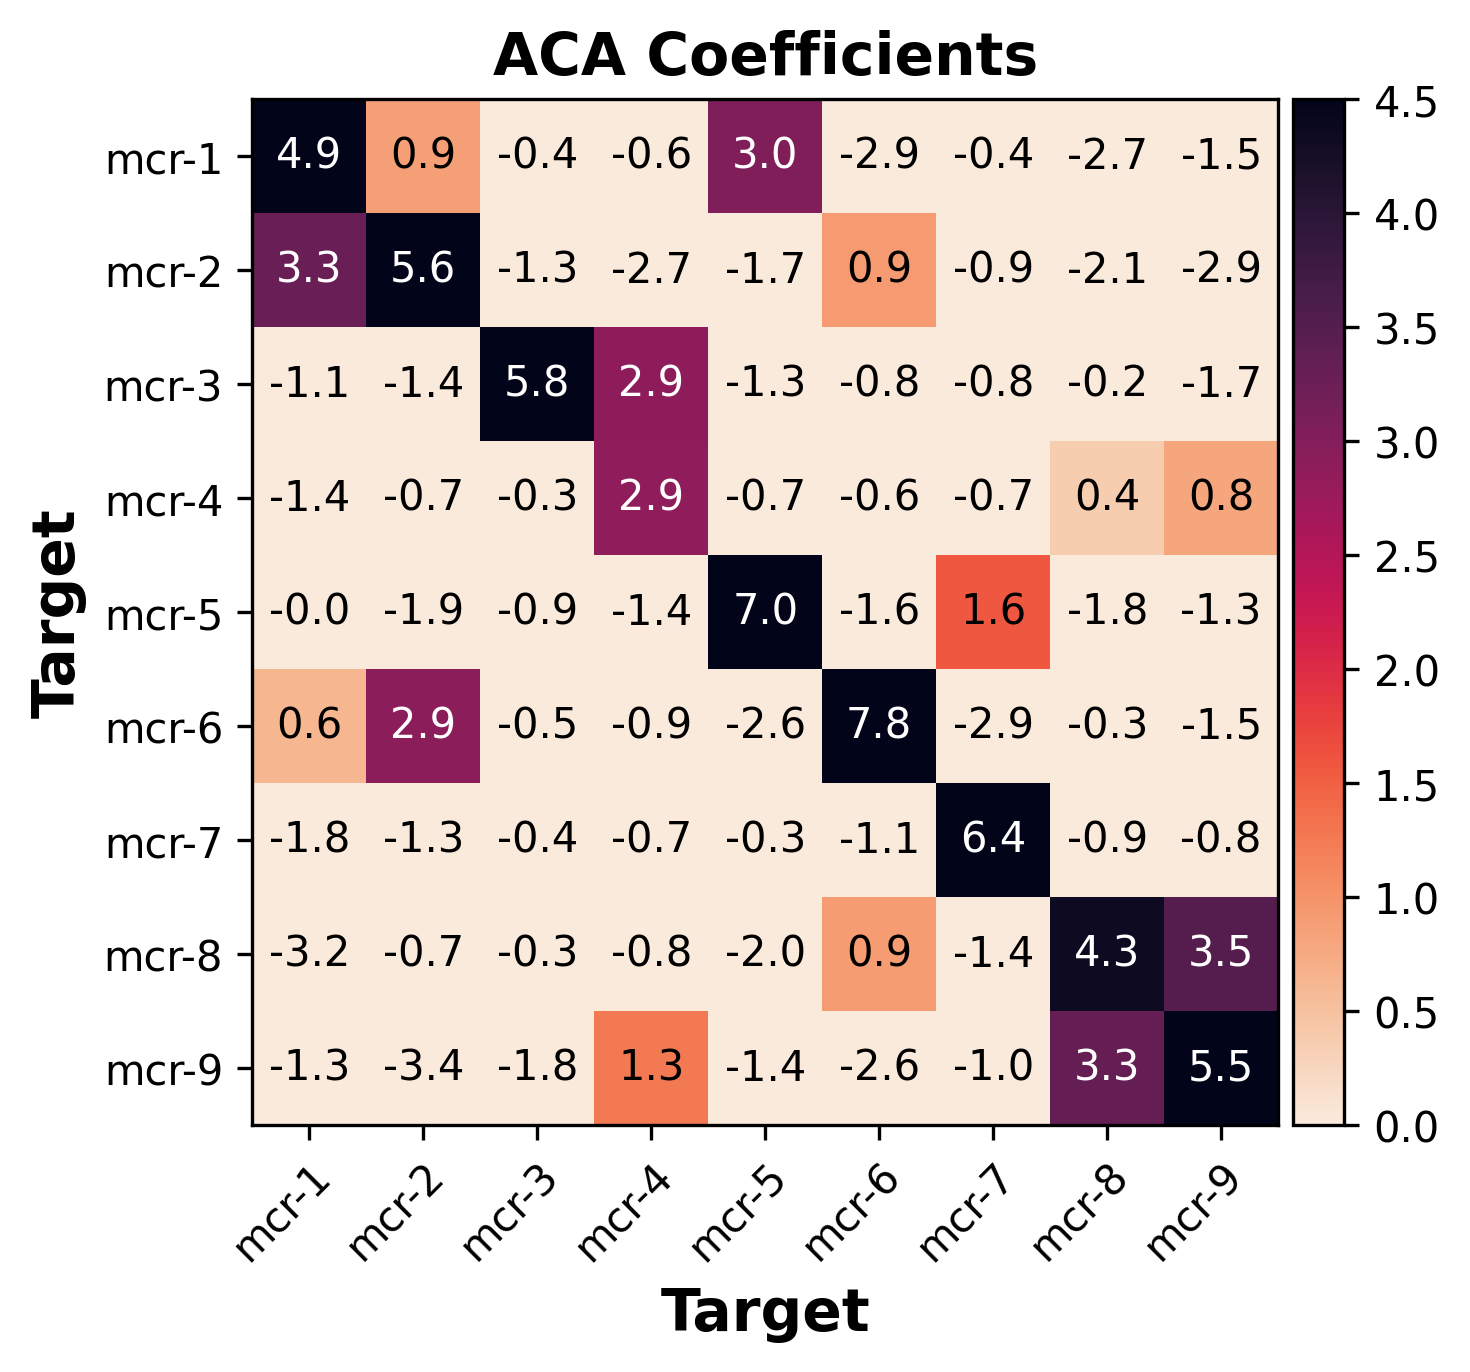

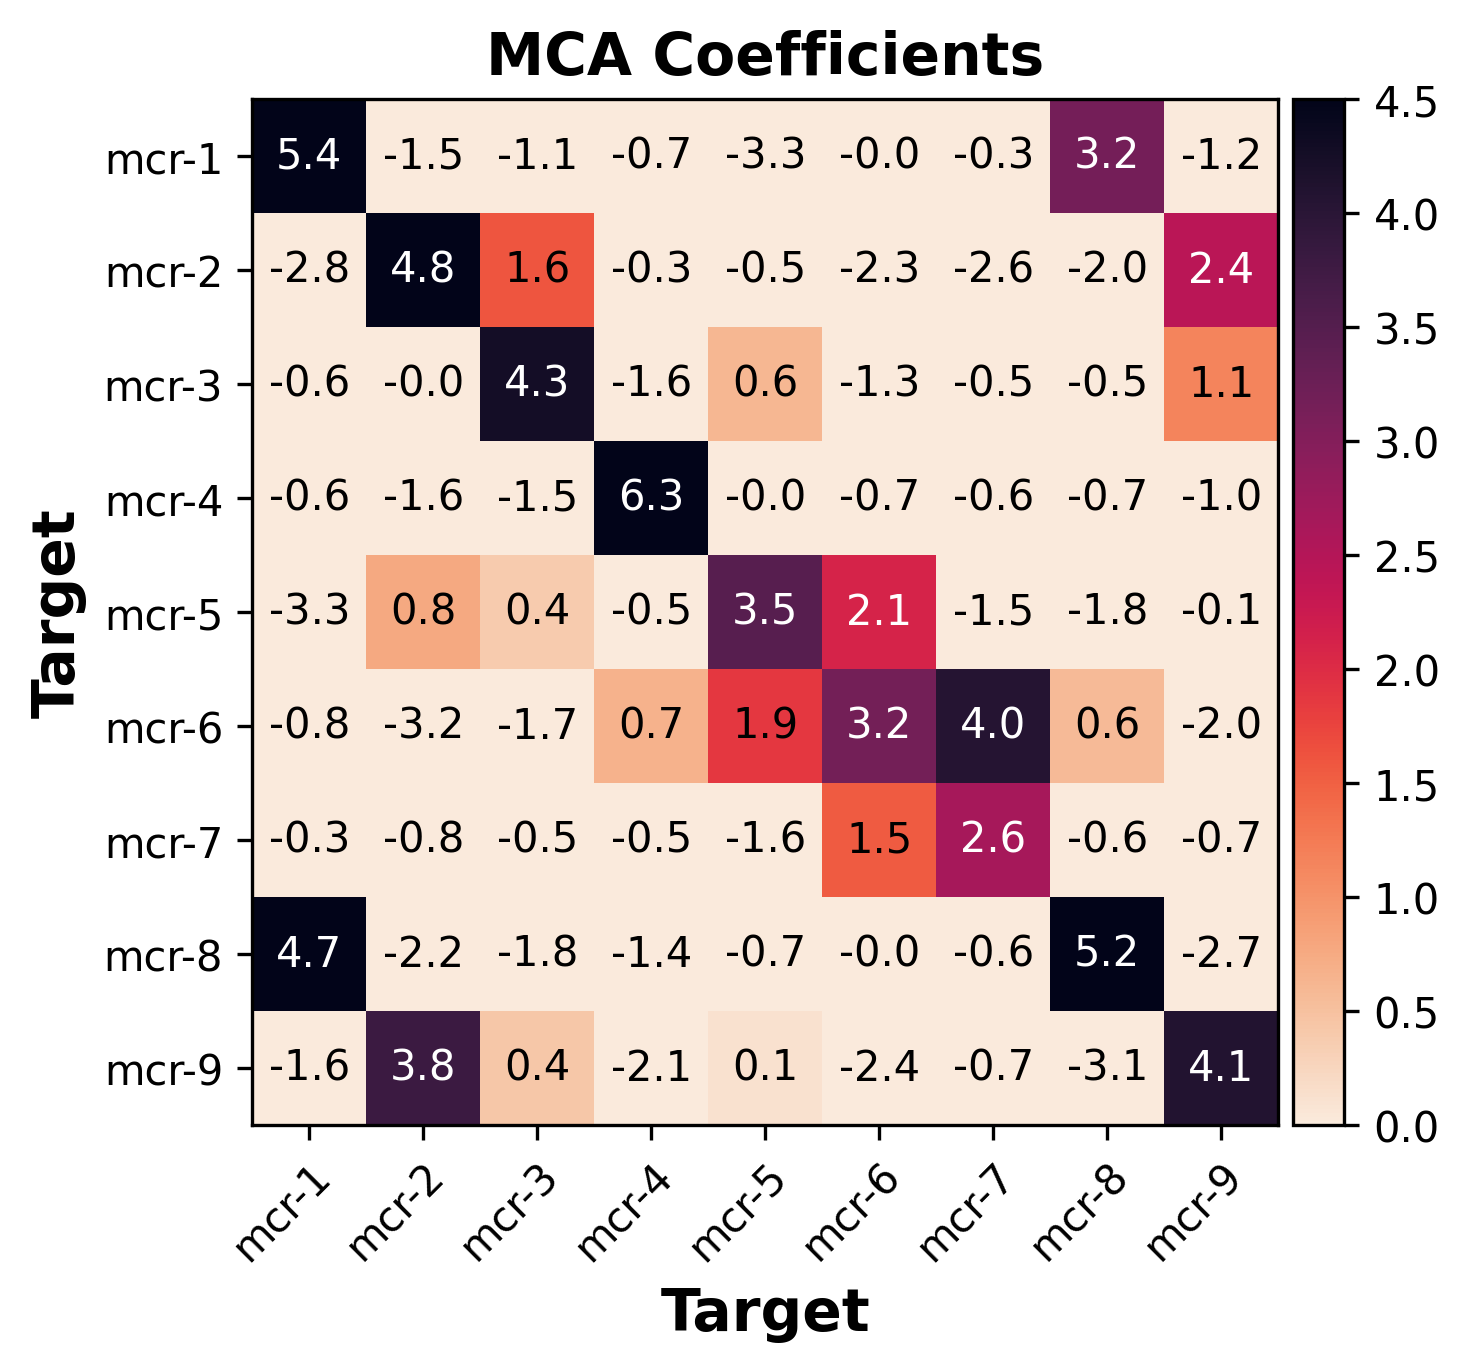

In [ ]:
ACA_coef = clf.coef_[:,:9]
MCA_coef = clf.coef_[:,-9:]
    
coefs = [ACA_coef, MCA_coef]
short_names = ['ACA', 'MCA']
    
for coef, short_name in zip(coefs, short_names):
    
    fig, ax = plt.subplots(1, 1, figsize=(5, 5), dpi=300)

    ax.set_xticks(range(9))
    ax.set_yticks(range(9))
    ax.set_xticklabels(classes)
    ax.set_yticklabels(classes)
    utils.my_heatmap(coef, ax, sns.cm.rocket_r)
    ax.set_title(f'{short_name} Coefficients', fontsize=14, weight='bold')
    ax.set_ylabel('Target', fontsize=14, weight='bold')
    ax.set_xlabel('Target', fontsize=14, weight='bold')

    plt.tight_layout()
    plt.savefig(f'Images/dPCR_{short_name}_coeffs.pdf')
    plt.show()

## Compute Performance as a Function of Training Volume

In [122]:
from sklearn.model_selection import StratifiedShuffleSplit
import datetime

n_total = len(X_AC)
assert len(X_AC)==len(X_MC)==len(X_FFI), "Something is wrong!"

n_repeat = 1
n_train_sizes = 20
test_size = 5000

train_size = (10**np.linspace(2, np.log10(n_total-test_size), num=n_train_sizes))/n_total
# train_size = np.linspace(50, n_total-test_size, num=n_train_sizes) / n_total

accuracy = pd.DataFrame(columns = ['Method', 'TrainSize', 'Train/Test', 'Accuracy', 'Repeat ID'])

for size in tqdm(train_size, desc='Train Size Split'):
    
    sss = StratifiedShuffleSplit(n_splits=n_repeat, test_size=test_size/n_total, random_state=5)

    for split_id, (train_index, test_index) in tqdm(enumerate(sss.split(X_AC, ytrue)), 
                                                    total=n_repeat, desc='Repeat', leave=False):
        
        X_MC_train, X_MC_test = X_MC[train_index], X_MC[test_index]
        X_AC_train, X_AC_test = X_AC[train_index], X_AC[test_index]
        X_FFI_train, X_FFI_test = X_FFI[train_index], X_FFI[test_index]

        y_train, y_test = ytrue[train_index], ytrue[test_index]

        X_MC_train = X_MC_train[:int(len(X_MC_train)*size), :]
        X_AC_train = X_AC_train[:int(len(X_AC_train)*size), :]
        X_FFI_train = X_FFI_train[:int(len(X_FFI_train)*size), :]
        y_train = y_train[:int(len(y_train)*size)]

        ########## create/train model for MC ##########    
        clf_MC = LogisticRegression(max_iter=1000, solver='lbfgs', 
                                    multi_class='auto')
        clf_MC.fit(X_MC_train, y_train)
        clf_MC_proba = clf_MC.predict_proba(X_MC_train)

        ########## create/train model for AC ##########
        clf_AC = myWrapper(build_fn=create_model, 
                                epochs=800, 
                                batch_size=512, 
                                shuffle=True,
                                verbose=False)

#         clf_AC = KNeighborsClassifier(n_neighbors=10)
        clf_AC.fit(X_AC_train, y_train)
        clf_AC_proba = clf_AC.predict_proba(X_AC_train)

        ########## create/train model for FFI ##########
        clf_FFI = LogisticRegression(max_iter=1000, solver='lbfgs', 
                                    multi_class='auto')
        clf_FFI.fit(X_FFI_train, y_train)
        clf_FFI_proba = clf_FFI.predict_proba(X_FFI_train)

        ########## create/train model for AMCA ##########
        X_AMCA_train = np.concatenate((clf_MC_proba, clf_AC_proba), axis=1)

        clf = LogisticRegression(max_iter=1000, fit_intercept=False, 
                                 solver='lbfgs', multi_class='auto')
    #     clf = LogisticRegressionCV(max_iter=2000, fit_intercept=False,
    #                                cv=StratifiedKFold(n_splits=5, shuffle=True))

        clf.fit(X_AMCA_train, y_train)
        clf_proba = clf.predict_proba(X_AMCA_train)

        # clf_MC_proba.argmax(axis=1) is the same as clf_MC.predict(X_MC_train)
        MCA_train_accuracy = (clf_MC_proba.argmax(axis=1)==y_train).mean()
        ACA_train_accuracy = (clf_AC_proba.argmax(axis=1)==y_train).mean()
        FFI_train_accuracy = (clf_FFI_proba.argmax(axis=1)==y_train).mean()
        AMCA_train_accuracy = (clf_proba.argmax(axis=1)==y_train).mean()
            
        MCA_test_accuracy = (clf_MC.predict(X_MC_test)==y_test).mean()
        ACA_test_accuracy = (clf_AC.predict(X_AC_test)==y_test).mean()
        FFI_test_accuracy = (clf_FFI.predict(X_FFI_test)==y_test).mean()
        
        X_AMCA_test = np.concatenate((clf_MC.predict_proba(X_MC_test), 
                                      clf_AC.predict_proba(X_AC_test)), axis=1)
        AMCA_test_accuracy = (clf.predict(X_AMCA_test)==y_test).mean()
    
                
        df_ = pd.DataFrame({'Method': ['MCA', 'MCA', 'ACA', 'ACA', 'FFI', 'FFI', 'AMCA', 'AMCA'],
                      'TrainSize': [len(y_train) for i in range(8)],
                      'Train/Test': ['Train', 'Test']*4,
                      'Accuracy': [MCA_train_accuracy, MCA_test_accuracy, 
                                   ACA_train_accuracy, ACA_test_accuracy, 
                                   FFI_train_accuracy, FFI_test_accuracy, 
                                   AMCA_train_accuracy, AMCA_test_accuracy],
                      'Repeat ID': [split_id for i in range(8)]
                     })
                
        accuracy = pd.concat([accuracy, df_], ignore_index=True)
        
        df_.to_csv(datetime.datetime.now().strftime("Data/vol-%d_%b_%Y_%H_%M_%S.csv"))
        

Train Size Split:   0%|          | 0/20 [00:00<?, ?it/s]/Users/kautsarg/Library/CloudStorage/OneDrive-ImperialCollegeLondon/Final Project/3. Initial code/titan-signal-processing-main/venv_titan/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/kautsarg/Library/CloudStorage/OneDrive-ImperialCollegeLondon/Final Project/3. Initial code/titan-signal-processing-main/venv_titan/lib/python3.12/site-packages/scikeras/wrappers.py:925: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)
/Users/kautsarg/Library/CloudStorage/OneDrive-ImperialCollegeLondon/Final Project/3. Initial code/titan-signal-processing-main/venv_titan/lib/python3.12/site-packages/

/var/folders/xt/t6fw9lz91vg0ryq45tpjcjpc0000gn/T/ipykernel_24513/2379104392.py:12: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(x="TrainSize", y="Accuracy",
/var/folders/xt/t6fw9lz91vg0ryq45tpjcjpc0000gn/T/ipykernel_24513/2379104392.py:12: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(x="TrainSize", y="Accuracy",
/var/folders/xt/t6fw9lz91vg0ryq45tpjcjpc0000gn/T/ipykernel_24513/2379104392.py:12: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(x="TrainSize", y="Accuracy",
/var/folders/xt/t6fw9lz91vg0ryq45tpjcjpc0000gn/T/ipykernel_24513/2379104392.py:12: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(x="TrainSize", y="Accuracy",


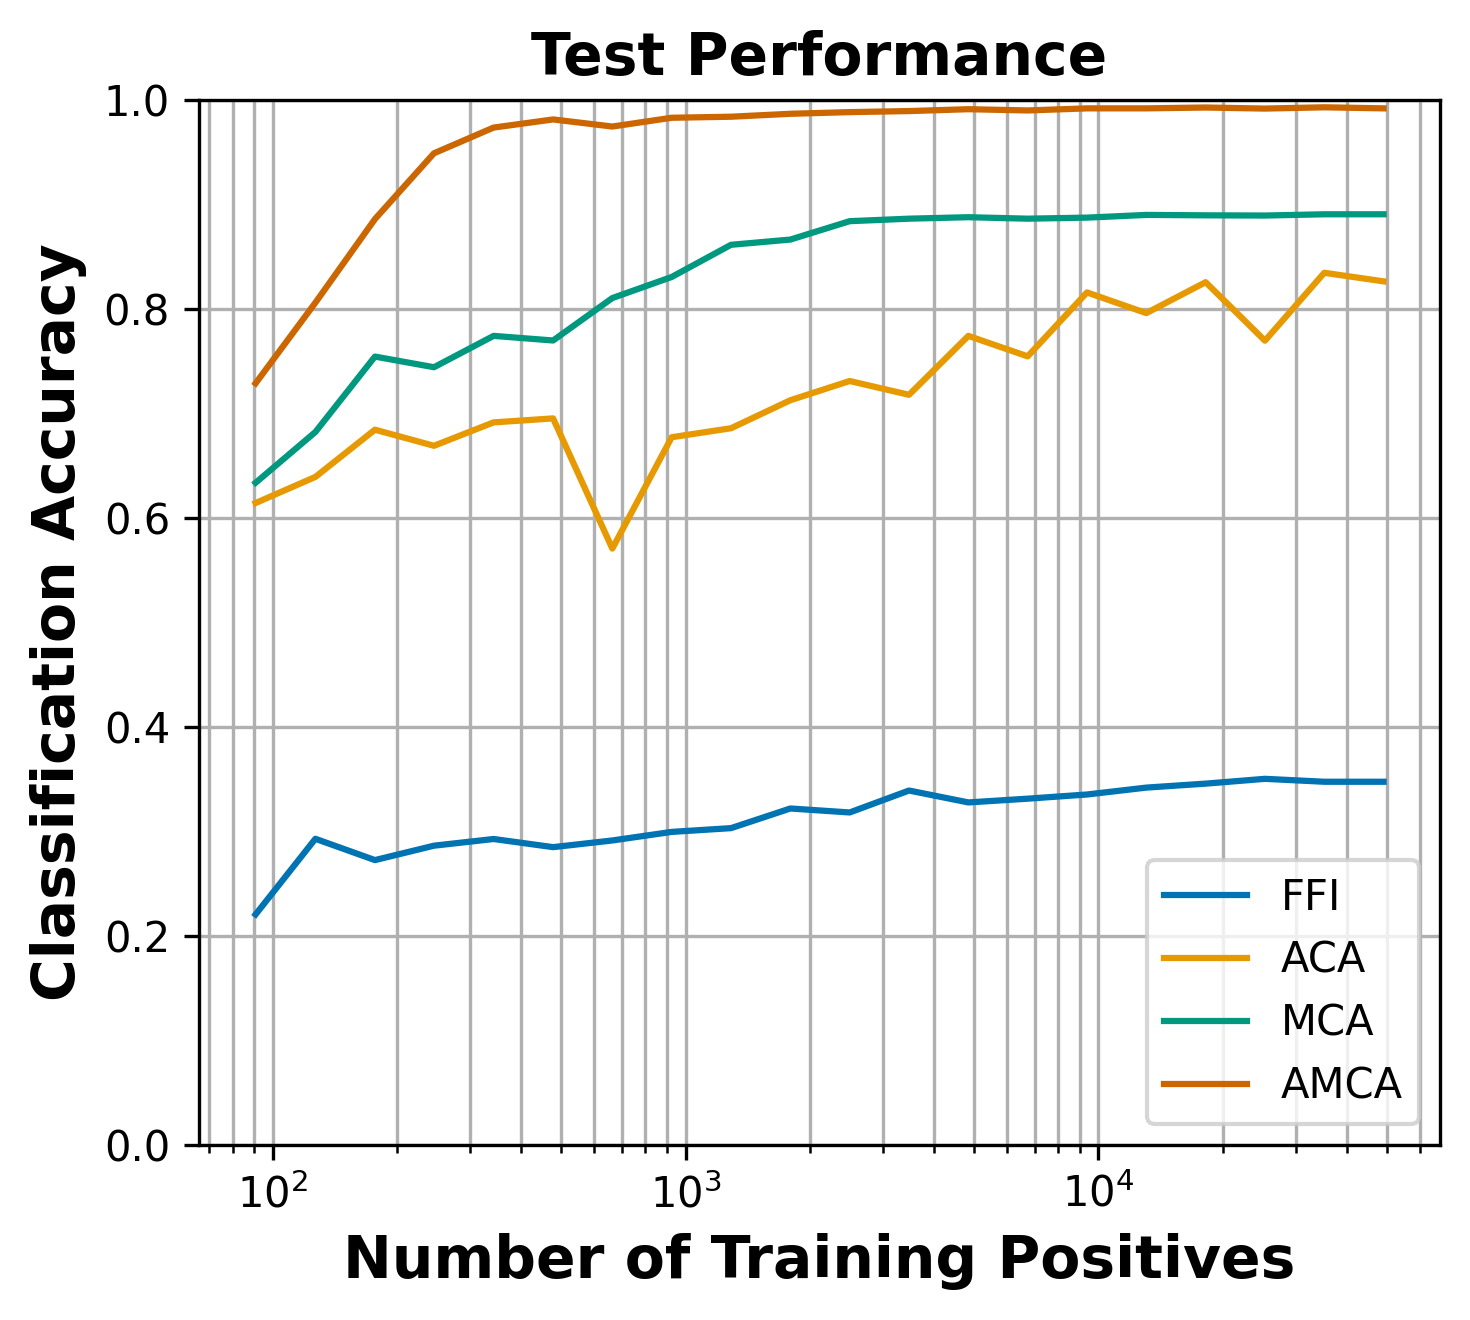

In [123]:
accuracy.to_csv("Data/dPCR_accuracy.csv")
accuracy = pd.read_csv('Data/dPCR_accuracy.csv')

methods = ['FFI', 'ACA', 'MCA', 'AMCA']

fig, ax = plt.subplots(1, 1, figsize=(5, 4.5), dpi=300)

ax.set_title('Test Performance', fontsize=14, weight='bold')
for i, method in enumerate(methods):
    df_ = accuracy[accuracy['Method'] == method]
    
    sns.lineplot(x="TrainSize", y="Accuracy", 
                 data=df_[df_['Train/Test'] == 'Test'], 
                 label=method, ci='sd', ax=ax)

ax.set_ylabel('Classification Accuracy', fontsize=14, weight='bold')
ax.set_xlabel('Number of Training Positives', fontsize=14, weight='bold')
ax.set_ylim((0., 1.0))
ax.set_xscale('log')
ax.grid(which="both", axis="both")
ax.get_legend()

# plt.subplots_adjust(wspace=0.2)
plt.tight_layout()
plt.savefig('Images/dPCR_Effect_of_Volume.pdf')
plt.show()